In [36]:
import cv2
import os
import matplotlib.pyplot as plt
import numpy as np
from skimage.metrics import peak_signal_noise_ratio
from skimage.metrics import structural_similarity

In [37]:
train_folder_path_x = "/kaggle/input/cv-project-data/low_resolution"
train_folder_path_y = "/kaggle/input/cv-project-data/high_resolution"
train_tuple = []
test_tuple = []

In [38]:
class MyDataLoader():
    def make_training_data(self):
        for f in os.listdir(train_folder_path_x):
            image_path_x = os.path.join(train_folder_path_x, f)
            image_path_y = os.path.join(train_folder_path_y, f)
            image_x = cv2.imread(image_path_x)
            image_y = cv2.imread(image_path_y)
            train_tuple.append((image_x, image_y))
                
dataLoader = MyDataLoader()
dataLoader.make_training_data()

In [39]:
print(len(train_tuple))
print((train_tuple[20][0]).shape)
print((train_tuple[20][1]).shape)

900
(128, 128, 3)
(512, 512, 3)


In [43]:
def upsample_bicubic(image_x, scale=4):
    h, w = image_x.shape[:2]
    new_w, new_h = int(w * scale), int(h * scale)
    # Upsample using Bicubic interpolation
    pred = cv2.resize(image_x, (new_w, new_h), interpolation=cv2.INTER_CUBIC)
    return pred

In [44]:
# Evaluation function
def loss_and_y_pred():
    l1_total = 0
    l2_total = 0
    psnr = 0
    ssim = 0

    for x_train, y_train in train_tuple:
        pred = upsample_bicubic(x_train)  # Using spline interpolation
        pred = np.array(pred)
        y_train = np.array(y_train)
        
        l1_loss = np.mean(np.abs(pred - y_train))
        l2_loss = np.mean((pred - y_train) ** 2)
        psnr += peak_signal_noise_ratio(y_train, pred, data_range=255)
        ssim += structural_similarity(y_train, pred, channel_axis=-1, data_range=255)
        
        l1_total += l1_loss
        l2_total += l2_loss

    l1_avg = l1_total / len(train_tuple)
    l2_avg = l2_total / len(train_tuple)
    psnr_avg = psnr / len(train_tuple)
    ssim_avg = ssim / len(train_tuple)
    return l1_avg, l2_avg, psnr_avg, ssim_avg

In [46]:
l1_avg, l2_avg, psnr_avg, ssim_avg = loss_and_y_pred()
print("Bicubic Interpolation Results:")
print("l1_loss:", l1_avg)
print("l2_loss:", l2_avg)
print("psnr_avg:", psnr_avg)
print("ssim_avg:", ssim_avg)

Bicubic Interpolation Results:
l1_loss: 75.85777279606566
l2_loss: 41.26254132023568
psnr_avg: 22.490423468703675
ssim_avg: 0.7123265147790755


In [47]:
# Individual image display for closer inspection
def show_single_image(index):
    x_train = train_tuple[index][0]
    y_pred = upsample_bicubic(x_train)
    y_train = train_tuple[index][1]
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    axes[0].imshow(cv2.cvtColor(x_train, cv2.COLOR_BGR2RGB))
    axes[0].set_title("Low Resolution")
    axes[0].axis('off')
    
    axes[1].imshow(cv2.cvtColor(y_pred, cv2.COLOR_BGR2RGB))
    axes[1].set_title("Bicubic Upsampled")
    axes[1].axis('off')
    
    axes[2].imshow(cv2.cvtColor(y_train, cv2.COLOR_BGR2RGB))
    axes[2].set_title("Ground Truth")
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()

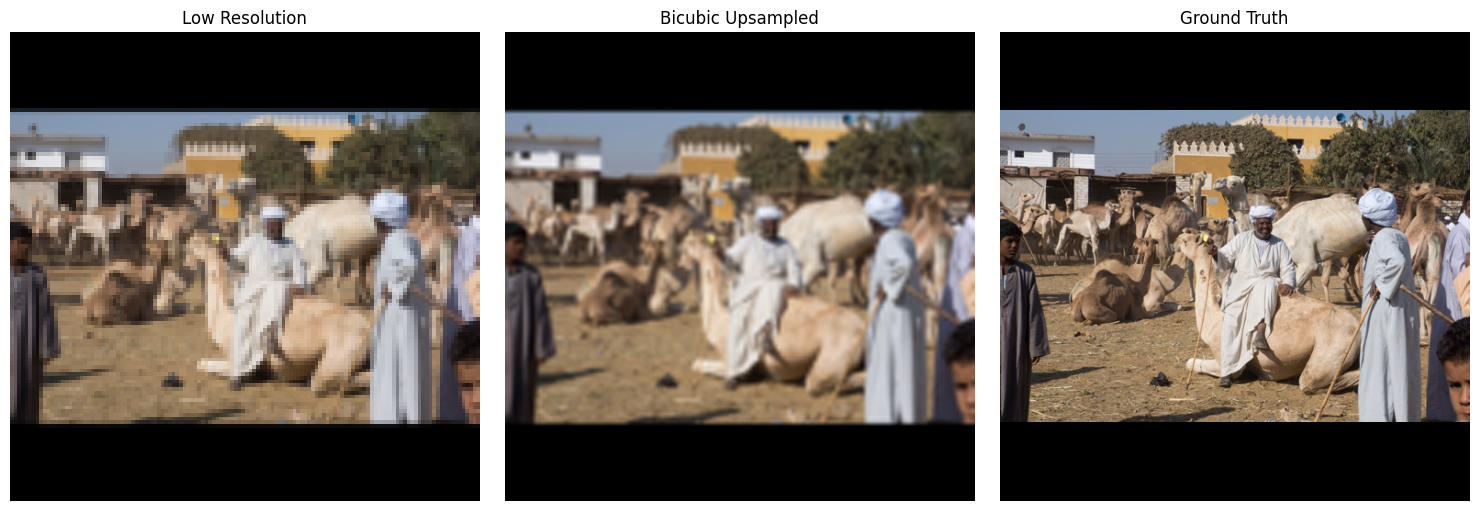

In [49]:
show_single_image(15)